<a href="https://colab.research.google.com/github/jashvidesai2030/IEMS499Spring/blob/main/newquadraticprob.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 47.9 MB/s eta 0:00:00


========== 2D ==========
Original BQP:
x = [1. 0.]
objective = -2.0
Diagonal PSD cut delta = [1.3 1.3]

Tangent-cover round 1
Current LP xbar = [1.       0.085714]
Current LP objective = -2.085714
Accepted tangent cuts so far = 0
BQP clique cuts added = 0
BQP cut inequalities added = 2
Tangent coefficients a = [4.32     1.842857]
Transformed knapsack RHS B = 4.634694
Number of cover candidates found = 1

Most violated candidate cuts this round:
  Candidate 1: violation = 0.085714, C_plus = [0, 1], C_minus = [], rho = 0.0, E_plus = [], E_minus = []

Adding cuts:
  Added cut with violation = 0.085714
    C_plus = [0, 1]
    C_minus = []
    rho = 0.0
    E_plus = []
    E_minus = []

Tangent-cover round 2
Current LP xbar = [1. 0.]
Current LP objective = -2.0
Accepted tangent cuts so far = 1
BQP clique cuts added = 0
BQP cut inequalities added = 2
Tangent coefficients a = [4.2 1.5]
Transformed knapsack RHS B = 4.5
Number of cover candidates found = 1

Most violated candidate cuts this rou

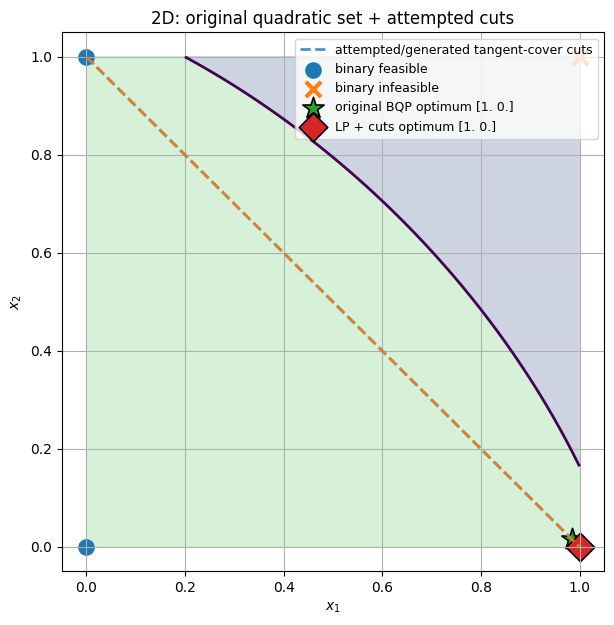


========== 3D ==========
Original BQP:
x = [0. 1. 0.]
objective = -1.0
Diagonal PSD cut delta = [ 1.7 -1.3  0.4]

Tangent-cover round 1
Current LP xbar = [0.422222 0.       1.      ]
Current LP objective = -1.422222
Accepted tangent cuts so far = 0
BQP clique cuts added = 2
BQP cut inequalities added = 12
Tangent coefficients a = [3.877778 5.911111 4.268889]
Transformed knapsack RHS B = 6.881975
Number of cover candidates found = 3

Most violated candidate cuts this round:
  Candidate 1: violation = 0.422222, C_plus = [0, 1], C_minus = [], rho = 1.0, E_plus = [2], E_minus = []
  Candidate 2: violation = 0.422222, C_plus = [0, 2], C_minus = [], rho = 1.0, E_plus = [1], E_minus = []
  Candidate 3: violation = 0.422222, C_plus = [1, 2], C_minus = [], rho = 1.0, E_plus = [0], E_minus = []

Adding cuts:
  Added cut with violation = 0.422222
    C_plus = [0, 1]
    C_minus = []
    rho = 1.0
    E_plus = [2]
    E_minus = []
  Added cut with violation = 0.422222
    C_plus = [0, 2]
    C_mi

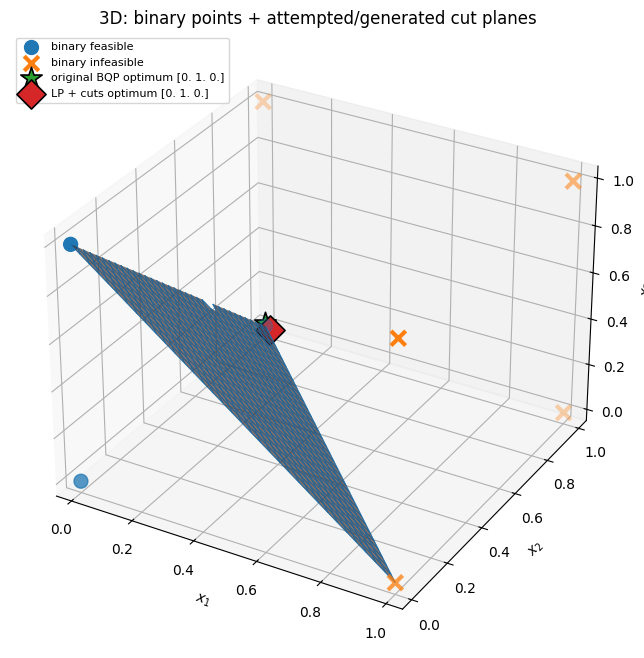


Number of accepted tangent cuts: 3
Number of attempted tangent cuts: 6

Attempted cut 1:
{'round': 1, 'candidate': 1, 'xbar': array([0.42222222, 0.        , 1.        ]), 'C_plus': [0, 1], 'C_minus': [], 'rho': 1.0, 'E_plus': [2], 'E_minus': [], 'cover_weight': 9.78888888888889, 'B': 6.881975308641975, 'lhs_at_xbar': 1.4222222222222223, 'rhs': 1.0, 'violation': 0.4222222222222223}

Attempted cut 2:
{'round': 1, 'candidate': 2, 'xbar': array([0.42222222, 0.        , 1.        ]), 'C_plus': [0, 2], 'C_minus': [], 'rho': 1.0, 'E_plus': [1], 'E_minus': [], 'cover_weight': 8.146666666666667, 'B': 6.881975308641975, 'lhs_at_xbar': 1.4222222222222223, 'rhs': 1.0, 'violation': 0.4222222222222223}

Attempted cut 3:
{'round': 1, 'candidate': 3, 'xbar': array([0.42222222, 0.        , 1.        ]), 'C_plus': [1, 2], 'C_minus': [], 'rho': 1.0, 'E_plus': [0], 'E_minus': [], 'cover_weight': 10.18, 'B': 6.881975308641975, 'lhs_at_xbar': 1.4222222222222223, 'rhs': 1.0, 'violation': 0.4222222222222223}

In [4]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB


# ============================================================
# Basic helpers
# ============================================================

def quad_value(x, Q, c):
    x = np.array(x)
    return x @ Q @ x + c @ x


def all_binary_points(n):
    return list(itertools.product([0, 1], repeat=n))


def offset_point(x, offset):
    if x is None:
        return None
    return np.clip(np.array(x) + np.array(offset), 0, 1)


def pair_key(i, j):
    return (i, j) if i < j else (j, i)


def pairs_in_set(S):
    return list(itertools.combinations(sorted(S), 2))


def compute_diagonal_psd_cut(Q):
    n = Q.shape[0]

    try:
        import cvxpy as cp

        delta = cp.Variable(n)
        constraints = [Q - cp.diag(delta) >> 0]
        prob = cp.Problem(cp.Maximize(cp.sum(delta)), constraints)
        prob.solve(solver=cp.SCS, verbose=False)

        if delta.value is not None:
            delta_val = np.array(delta.value)

            if np.linalg.eigvalsh(Q - np.diag(delta_val)).min() >= -1e-6:
                return delta_val

    except Exception:
        pass

    lam = np.linalg.eigvalsh(Q).min()
    return lam * np.ones(n)


# ============================================================
# Model 1: Original binary quadratic model
# ============================================================

def solve_original_bqp(w, Q, c, e):
    n = len(w)

    m = gp.Model("original_binary_quadratic")
    m.Params.OutputFlag = 0

    x = m.addVars(n, vtype=GRB.BINARY, name="x")

    m.setObjective(gp.quicksum(w[i] * x[i] for i in range(n)), GRB.MINIMIZE)

    quad = gp.quicksum(Q[i, j] * x[i] * x[j] for i in range(n) for j in range(n))
    lin = gp.quicksum(c[i] * x[i] for i in range(n))

    m.addQConstr(quad + lin <= e, name="quad_constraint")

    m.optimize()

    if m.Status == GRB.OPTIMAL:
        return np.array([x[i].X for i in range(n)]), m.ObjVal

    return None, None


# ============================================================
# Tangent-cover helpers
# ============================================================

def transformed_weight_vector(Q, c, xbar):
    return c + 2 * Q @ xbar


def transformed_knapsack_rhs(Q, c, e, xbar, a):
    M = [i for i in range(len(c)) if a[i] < -1e-9]
    return e + xbar @ Q @ xbar - sum(a[i] for i in M)

def generate_tangent_cover_candidates(
    Q, c, e, xbar,
    max_cover_size=None,
    minimal_only=True
):
    """
    Generate MANY tangent-cover candidates from the tangent inequality at xbar.

    This fixes the old issue:
        old code found only the first greedy cover.

    New logic:
        1. Build transformed positive-coefficient knapsack.
        2. Enumerate many covers.
        3. Optionally keep only minimal covers.
        4. Return all candidate (C_plus, C_minus) covers.

    A cover is any set whose transformed weight exceeds B.
    """
    n = len(c)

    a = transformed_weight_vector(Q, c, xbar)
    B = transformed_knapsack_rhs(Q, c, e, xbar, a)

    items = []

    for i in range(n):
        if a[i] > 1e-9:
            items.append((i, "plus", a[i]))
        elif a[i] < -1e-9:
            items.append((i, "minus", -a[i]))

    if max_cover_size is None:
        max_cover_size = len(items)

    covers = []

    # Enumerate candidate covers.
    for r in range(1, min(max_cover_size, len(items)) + 1):
        for subset in itertools.combinations(items, r):
            weight = sum(item[2] for item in subset)

            if weight > B + 1e-9:
                C_plus = [idx for idx, sign, wt in subset if sign == "plus"]
                C_minus = [idx for idx, sign, wt in subset if sign == "minus"]

                covers.append({
                    "C_plus": C_plus,
                    "C_minus": C_minus,
                    "a": a,
                    "B": B,
                    "cover_weight": weight
                })

    # Remove non-minimal covers if requested.
    if minimal_only:
        minimal_covers = []

        for cover in covers:
            C = set(cover["C_plus"]).union(set(cover["C_minus"]))

            is_minimal = True

            for other in covers:
                D = set(other["C_plus"]).union(set(other["C_minus"]))

                if D < C:
                    is_minimal = False
                    break

            if is_minimal:
                minimal_covers.append(cover)

        covers = minimal_covers

    return covers, a, B


def compute_best_simultaneous_rho(Q, c, e, xbar, C_plus, C_minus):
    n = len(c)

    a = transformed_weight_vector(Q, c, xbar)
    B = transformed_knapsack_rhs(Q, c, e, xbar, a)

    C = set(C_plus).union(set(C_minus))
    E = [i for i in range(n) if i not in C]

    E_plus = [i for i in E if a[i] > 1e-9]
    E_minus = [i for i in E if a[i] < -1e-9]

    if len(E) == 0:
        return 0.0, E_plus, E_minus

    rhs_cover = len(C_plus) + len(C_minus) - 1
    best_rho = float("inf")

    for z_tuple in all_binary_points(n):
        z = np.array(z_tuple)

        lhs_knap = 0.0

        for i in range(n):
            if a[i] > 1e-9:
                lhs_knap += a[i] * z[i]
            elif a[i] < -1e-9:
                lhs_knap += (-a[i]) * z[i]

        if lhs_knap <= B + 1e-9:
            cover_sum = sum(z[i] for i in C_plus) + sum(z[i] for i in C_minus)
            lift_sum = sum(z[i] for i in E_plus) + sum(z[i] for i in E_minus)

            if lift_sum > 1e-9:
                rho_bound = (rhs_cover - cover_sum) / lift_sum
                best_rho = min(best_rho, rho_bound)

    if best_rho == float("inf"):
        best_rho = 0.0

    return max(0.0, best_rho), E_plus, E_minus


def tangent_cut_lhs_value(x, cut):
    lhs = sum(x[i] for i in cut["C_plus"])
    lhs -= sum(x[i] for i in cut["C_minus"])
    lhs += cut["rho"] * sum(x[j] for j in cut["E_plus"])
    lhs -= cut["rho"] * sum(x[j] for j in cut["E_minus"])
    return lhs


def tangent_cut_rhs_value(cut):
    return len(cut["C_plus"]) - 1 - cut["rho"] * len(cut["E_minus"])


def tangent_cut_key(cut):
    return (
        tuple(sorted(cut["C_plus"])),
        tuple(sorted(cut["C_minus"])),
        tuple(sorted(cut["E_plus"])),
        tuple(sorted(cut["E_minus"])),
        round(float(cut["rho"]), 8)
    )


def cut_to_alpha_beta(cut, n):
    """
    Converts lifted tangent-cover cut into alpha^T x <= beta.
    """
    alpha = np.zeros(n)

    for i in cut["C_plus"]:
        alpha[i] += 1

    for i in cut["C_minus"]:
        alpha[i] -= 1

    for j in cut["E_plus"]:
        alpha[j] += cut["rho"]

    for j in cut["E_minus"]:
        alpha[j] -= cut["rho"]

    beta = len(cut["C_plus"]) - 1 - cut["rho"] * len(cut["E_minus"])

    return alpha, beta


# ============================================================
# Boolean Quadric Polytope cuts
# ============================================================

def add_bqp_clique_cuts(m, x, y, n, max_subset_size=4):
    count = 0

    for size in range(3, min(n, max_subset_size) + 1):
        for S in itertools.combinations(range(n), size):
            S = list(S)
            edge_pairs = pairs_in_set(S)

            for alpha in range(1, size):
                lhs = alpha * gp.quicksum(x[i] for i in S)
                lhs -= gp.quicksum(y[pair_key(i, j)] for i, j in edge_pairs)

                rhs = alpha * (alpha + 1) / 2

                m.addConstr(lhs <= rhs, name=f"bqp_clique_{count}")
                count += 1

    return count


def add_bqp_cut_cuts(m, x, y, n, max_subset_size=4):
    count = 0
    N = list(range(n))

    for total_size in range(2, min(n, max_subset_size) + 1):
        for U in itertools.combinations(N, total_size):
            U = list(U)

            for r in range(1, total_size):
                for S_tuple in itertools.combinations(U, r):
                    S = set(S_tuple)
                    T = set(U) - S

                    if len(T) == 0:
                        continue

                    cross_pairs = [(i, j) for i in S for j in T]
                    S_pairs = pairs_in_set(S)
                    T_pairs = pairs_in_set(T)

                    lhs = gp.quicksum(y[pair_key(i, j)] for i, j in cross_pairs)
                    lhs -= gp.quicksum(x[j] for j in T)
                    lhs -= gp.quicksum(y[pair_key(i, j)] for i, j in S_pairs)
                    lhs -= gp.quicksum(y[pair_key(i, j)] for i, j in T_pairs)

                    m.addConstr(lhs <= 0, name=f"bqp_cut_{count}")
                    count += 1

    return count


# ============================================================
# Model 2: Linearized LP relaxation + iterative tangent cuts
# ============================================================

def solve_linearized_lp_with_cuts(
    w, Q, c, e,
    add_triangle=True,
    add_diagonal_psd_cut=True,
    add_bqp_clique=True,
    add_bqp_cut=True,
    bqp_max_subset_size=4,
    auto_tangent_cover=True,
    add_simultaneous_lifting=True,
    max_cut_rounds=10,
    cut_tol=1e-6,
    max_cover_size=None,
    max_cuts_per_round=5,
    minimal_covers_only=True
):
    """
    Solves the LP relaxation with static cuts plus iterative tangent-cover cuts.

    Main improvement:
        At each LP solution xbar, we now generate MANY candidate tangent covers,
        compute their violations, and add the most violated cuts.

    So max_cut_rounds=10 now really means:
        re-solve up to 10 times, adding violated cuts each round if found.
    """

    n = len(w)

    delta = None
    if add_diagonal_psd_cut:
        delta = compute_diagonal_psd_cut(Q)
        print("Diagonal PSD cut delta =", np.round(delta, 4))

    tangent_cuts = []       # accepted cuts added to the LP
    attempted_cuts = []     # every generated cut candidate
    seen_cut_keys = set()

    def build_and_solve(current_tangent_cuts):
        """
        Rebuilds the LP from scratch with all current cuts.
        """
        m = gp.Model("linearized_lp_with_cuts")
        m.Params.OutputFlag = 0

        x = m.addVars(n, lb=0, ub=1, vtype=GRB.CONTINUOUS, name="x")

        y = {}
        for i in range(n):
            for j in range(i + 1, n):
                y[i, j] = m.addVar(lb=0, ub=1, vtype=GRB.CONTINUOUS, name=f"y_{i}_{j}")

        m.setObjective(gp.quicksum(w[i] * x[i] for i in range(n)), GRB.MINIMIZE)

        # Linearized quadratic constraint
        d = np.diag(Q) + c

        lhs_quad = gp.quicksum(d[i] * x[i] for i in range(n))
        lhs_quad += gp.quicksum(
            2 * Q[i, j] * y[i, j]
            for i in range(n)
            for j in range(i + 1, n)
        )

        m.addConstr(lhs_quad <= e, name="linearized_quad")

        # McCormick constraints
        for i in range(n):
            for j in range(i + 1, n):
                m.addConstr(y[i, j] <= x[i])
                m.addConstr(y[i, j] <= x[j])
                m.addConstr(y[i, j] >= x[i] + x[j] - 1)
                m.addConstr(y[i, j] >= 0)

        # Triangle inequalities
        if add_triangle:
            for i in range(n):
                for j in range(i + 1, n):
                    for k in range(j + 1, n):
                        m.addConstr(y[i, j] + y[i, k] - y[j, k] <= x[i])
                        m.addConstr(y[i, j] + y[j, k] - y[i, k] <= x[j])
                        m.addConstr(y[i, k] + y[j, k] - y[i, j] <= x[k])
                        m.addConstr(
                            y[i, j] + y[i, k] + y[j, k]
                            >= x[i] + x[j] + x[k] - 1
                        )

        # BQP clique inequalities
        if add_bqp_clique:
            num_clique = add_bqp_clique_cuts(
                m, x, y, n,
                max_subset_size=bqp_max_subset_size
            )
        else:
            num_clique = 0

        # BQP cut inequalities
        if add_bqp_cut:
            num_cut = add_bqp_cut_cuts(
                m, x, y, n,
                max_subset_size=bqp_max_subset_size
            )
        else:
            num_cut = 0

        # Diagonal PSD cut
        if add_diagonal_psd_cut and delta is not None:
            m.addConstr(
                gp.quicksum((delta[i] + c[i]) * x[i] for i in range(n)) <= e,
                name="diagonal_psd_cut"
            )

        # Accepted tangent-cover cuts
        for idx, cut in enumerate(current_tangent_cuts):
            alpha, beta = cut_to_alpha_beta(cut, n)

            m.addConstr(
                gp.quicksum(alpha[i] * x[i] for i in range(n)) <= beta,
                name=f"tangent_cover_cut_{idx}"
            )

        m.optimize()

        if m.Status == GRB.OPTIMAL:
            xsol = np.array([x[i].X for i in range(n)])
            ysol = {(i, j): y[i, j].X for (i, j) in y}

            info = {
                "num_bqp_clique": num_clique,
                "num_bqp_cut": num_cut,
                "num_tangent_cuts": len(current_tangent_cuts)
            }

            return xsol, ysol, m.ObjVal, info

        return None, None, None, None

    if not auto_tangent_cover:
        xsol, ysol, obj, info = build_and_solve([])
        return xsol, ysol, obj, [], [], info

    # ============================================================
    # Cutting-plane loop
    # ============================================================

    for round_id in range(max_cut_rounds):
        xbar, ybar, objbar, info = build_and_solve(tangent_cuts)

        if xbar is None:
            print("LP solve failed.")
            break

        print("\n========================================")
        print(f"Tangent-cover round {round_id + 1}")
        print("Current LP xbar =", np.round(xbar, 6))
        print("Current LP objective =", round(objbar, 6))
        print("Accepted tangent cuts so far =", len(tangent_cuts))
        print("BQP clique cuts added =", info["num_bqp_clique"])
        print("BQP cut inequalities added =", info["num_bqp_cut"])

        # Generate MANY covers instead of just one greedy cover.
        cover_candidates, a, B = generate_tangent_cover_candidates(
            Q, c, e, xbar,
            max_cover_size=max_cover_size,
            minimal_only=minimal_covers_only
        )

        print("Tangent coefficients a =", np.round(a, 6))
        print("Transformed knapsack RHS B =", round(B, 6))
        print("Number of cover candidates found =", len(cover_candidates))

        if len(cover_candidates) == 0:
            print("No tangent-cover candidates found. Stopping.")
            break

        candidate_cuts = []

        for cand_id, cand in enumerate(cover_candidates, start=1):
            C_plus = cand["C_plus"]
            C_minus = cand["C_minus"]

            if add_simultaneous_lifting:
                rho, E_plus, E_minus = compute_best_simultaneous_rho(
                    Q, c, e, xbar, C_plus, C_minus
                )
            else:
                rho, E_plus, E_minus = 0.0, [], []

            new_cut = {
                "round": round_id + 1,
                "candidate": cand_id,
                "xbar": xbar.copy(),
                "C_plus": C_plus.copy(),
                "C_minus": C_minus.copy(),
                "rho": float(rho),
                "E_plus": E_plus.copy(),
                "E_minus": E_minus.copy(),
                "cover_weight": float(cand["cover_weight"]),
                "B": float(B)
            }

            lhs_val = tangent_cut_lhs_value(xbar, new_cut)
            rhs_val = tangent_cut_rhs_value(new_cut)
            violation = lhs_val - rhs_val

            new_cut["lhs_at_xbar"] = float(lhs_val)
            new_cut["rhs"] = float(rhs_val)
            new_cut["violation"] = float(violation)

            attempted_cuts.append(new_cut.copy())
            candidate_cuts.append(new_cut.copy())

        # Sort by violation from largest to smallest.
        candidate_cuts.sort(key=lambda cut: cut["violation"], reverse=True)

        print("\nMost violated candidate cuts this round:")
        for k, cut in enumerate(candidate_cuts[:10], start=1):
            print(f"  Candidate {k}: violation = {round(cut['violation'], 6)}, "
                  f"C_plus = {cut['C_plus']}, C_minus = {cut['C_minus']}, "
                  f"rho = {round(cut['rho'], 6)}, "
                  f"E_plus = {cut['E_plus']}, E_minus = {cut['E_minus']}")

        # Keep only genuinely violated, nonduplicate cuts.
        violated_new_cuts = []

        for cut in candidate_cuts:
            if cut["violation"] <= cut_tol:
                continue

            key = tangent_cut_key(cut)

            if key in seen_cut_keys:
                continue

            violated_new_cuts.append(cut.copy())
            seen_cut_keys.add(key)

            if len(violated_new_cuts) >= max_cuts_per_round:
                break

        if len(violated_new_cuts) == 0:
            print("No violated tangent-cover cut found among candidates. Stopping.")
            break

        print("\nAdding cuts:")
        for cut in violated_new_cuts:
            print("  Added cut with violation =", round(cut["violation"], 6))
            print("    C_plus =", cut["C_plus"])
            print("    C_minus =", cut["C_minus"])
            print("    rho =", round(cut["rho"], 6))
            print("    E_plus =", cut["E_plus"])
            print("    E_minus =", cut["E_minus"])

        tangent_cuts.extend(violated_new_cuts)

    # Final solve after all accepted cuts.
    xsol, ysol, obj, info = build_and_solve(tangent_cuts)

    final_info = {
        "num_tangent_cuts": len(tangent_cuts),
        "num_attempted_cuts": len(attempted_cuts),
        "tangent_cuts": tangent_cuts,
        "attempted_cuts": attempted_cuts,
        "static_cut_info": info
    }

    return xsol, ysol, obj, tangent_cuts, attempted_cuts, final_info


# ============================================================
# Plotting: 2D
# ============================================================

def plot_2d_better(Q, c, e, x_orig=None, x_lp=None, cuts_to_plot=None):
    n = 2

    feasible, infeasible = [], []

    for p in all_binary_points(n):
        if quad_value(p, Q, c) <= e + 1e-9:
            feasible.append(p)
        else:
            infeasible.append(p)

    grid = np.linspace(0, 1, 400)
    X1, X2 = np.meshgrid(grid, grid)

    Z = np.zeros_like(X1)
    for a in range(len(grid)):
        for b in range(len(grid)):
            Z[a, b] = quad_value([X1[a, b], X2[a, b]], Q, c)

    plt.figure(figsize=(7, 7))

    plt.contourf(X1, X2, Z <= e, levels=[-0.5, 0.5, 1.5], alpha=0.25)
    plt.contour(X1, X2, Z, levels=[e], linewidths=2)

    if cuts_to_plot is not None:
        for cut_id, cut in enumerate(cuts_to_plot, start=1):
            alpha, beta = cut_to_alpha_beta(cut, n)
            xs = np.linspace(0, 1, 300)

            label = "attempted/generated tangent-cover cuts" if cut_id == 1 else None

            if abs(alpha[1]) > 1e-9:
                ys = (beta - alpha[0] * xs) / alpha[1]
                mask = (ys >= 0) & (ys <= 1)
                plt.plot(xs[mask], ys[mask], "--", linewidth=2, alpha=0.8, label=label)

            elif abs(alpha[0]) > 1e-9:
                xline = beta / alpha[0]
                if 0 <= xline <= 1:
                    plt.axvline(xline, linestyle="--", linewidth=2, alpha=0.8, label=label)

    if feasible:
        F = np.array(feasible)
        plt.scatter(F[:, 0], F[:, 1], s=120, label="binary feasible")

    if infeasible:
        I = np.array(infeasible)
        plt.scatter(I[:, 0], I[:, 1], s=120, marker="x", linewidths=3, label="binary infeasible")

    x_orig_plot = offset_point(x_orig, [-0.015, 0.015])
    x_lp_plot = offset_point(x_lp, [0.015, -0.015])

    if x_orig is not None:
        plt.scatter(
            x_orig_plot[0], x_orig_plot[1],
            s=260,
            marker="*",
            edgecolors="black",
            linewidths=1.2,
            label=f"original BQP optimum {np.round(x_orig, 3)}"
        )

    if x_lp is not None:
        plt.scatter(
            x_lp_plot[0], x_lp_plot[1],
            s=210,
            marker="D",
            edgecolors="black",
            linewidths=1.2,
            label=f"LP + cuts optimum {np.round(x_lp, 3)}"
        )

    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title("2D: original quadratic set + attempted cuts")
    plt.grid(True)
    plt.legend(loc="upper right", fontsize=9)
    plt.show()


# ============================================================
# Plotting: 3D
# ============================================================

def plot_3d_with_cut_planes(Q, c, e, x_orig=None, x_lp=None, cuts_to_plot=None):
    n = 3

    feasible, infeasible = [], []

    for p in all_binary_points(n):
        if quad_value(p, Q, c) <= e + 1e-9:
            feasible.append(p)
        else:
            infeasible.append(p)

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")

    if feasible:
        F = np.array(feasible)
        ax.scatter(F[:, 0], F[:, 1], F[:, 2], s=100, label="binary feasible")

    if infeasible:
        I = np.array(infeasible)
        ax.scatter(
            I[:, 0], I[:, 1], I[:, 2],
            s=110,
            marker="x",
            linewidths=3,
            label="binary infeasible"
        )

    if cuts_to_plot is not None:
        grid = np.linspace(0, 1, 35)

        for cut_id, cut in enumerate(cuts_to_plot, start=1):
            alpha, beta = cut_to_alpha_beta(cut, n)

            solve_idx = np.argmax(np.abs(alpha))

            if abs(alpha[solve_idx]) <= 1e-9:
                continue

            other = [i for i in range(3) if i != solve_idx]

            U, V = np.meshgrid(grid, grid)

            coords = [None, None, None]
            coords[other[0]] = U
            coords[other[1]] = V

            coords[solve_idx] = (
                beta
                - alpha[other[0]] * coords[other[0]]
                - alpha[other[1]] * coords[other[1]]
            ) / alpha[solve_idx]

            X, Y, Z = coords

            mask = (
                (X >= 0) & (X <= 1) &
                (Y >= 0) & (Y <= 1) &
                (Z >= 0) & (Z <= 1)
            )

            X_plot = np.where(mask, X, np.nan)
            Y_plot = np.where(mask, Y, np.nan)
            Z_plot = np.where(mask, Z, np.nan)

            ax.plot_surface(
                X_plot, Y_plot, Z_plot,
                alpha=0.16,
                linewidth=0,
                edgecolor="none"
            )

            ax.plot_wireframe(
                X_plot, Y_plot, Z_plot,
                linewidth=0.6,
                alpha=0.35
            )

    x_orig_plot = offset_point(x_orig, [-0.025, 0.015, 0.015])
    x_lp_plot = offset_point(x_lp, [0.025, -0.015, -0.015])

    if x_orig is not None:
        ax.scatter(
            x_orig_plot[0], x_orig_plot[1], x_orig_plot[2],
            s=260,
            marker="*",
            edgecolors="black",
            linewidths=1.2,
            label=f"original BQP optimum {np.round(x_orig, 3)}"
        )

    if x_lp is not None:
        ax.scatter(
            x_lp_plot[0], x_lp_plot[1], x_lp_plot[2],
            s=220,
            marker="D",
            edgecolors="black",
            linewidths=1.2,
            label=f"LP + cuts optimum {np.round(x_lp, 3)}"
        )

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_zlim(-0.05, 1.05)

    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_zlabel("$x_3$")

    ax.set_title("3D: binary points + attempted/generated cut planes")
    ax.legend(loc="upper left", fontsize=8)

    plt.show()


# ============================================================
# 2D example
# ============================================================

w2 = np.array([-2.0, -1.0])

Q2 = np.array(
    [[2.0, 0.7],
     [0.7, 2.0]]
)

c2 = np.array([0.2, 0.1])
e2 = 2.5

print("========== 2D ==========")

x_orig_2, obj_orig_2 = solve_original_bqp(w2, Q2, c2, e2)

print("Original BQP:")
print("x =", x_orig_2)
print("objective =", obj_orig_2)

x_lp_2, y_lp_2, obj_lp_2, tangent_cuts_2, attempted_cuts_2, info_2 = solve_linearized_lp_with_cuts(
    w2, Q2, c2, e2,
    add_triangle=True,
    add_diagonal_psd_cut=True,
    add_bqp_clique=True,
    add_bqp_cut=True,
    bqp_max_subset_size=4,
    auto_tangent_cover=True,
    add_simultaneous_lifting=True,
    max_cut_rounds=10
)

print("\nLP relaxation + cuts:")
print("x =", x_lp_2)
print("y =", y_lp_2)
print("objective =", obj_lp_2)
print("accepted tangent cuts =", tangent_cuts_2)
print("attempted tangent cuts =", attempted_cuts_2)

plot_2d_better(
    Q2, c2, e2,
    x_orig=x_orig_2,
    x_lp=x_lp_2,
    cuts_to_plot=attempted_cuts_2
)


# ============================================================
# 3D example
# ============================================================

w3 = np.array([-1.0, -1.0, -1.0])

Q3 = np.array([
    [4.0, 2.5, 0.2],
    [2.5, 3.0, 1.8],
    [0.2, 1.8, 2.0]
])

c3 = np.array([0.1, 0.2, 0.1])
e3 = 4.0

print("\n========== 3D ==========")

x_orig_3, obj_orig_3 = solve_original_bqp(w3, Q3, c3, e3)

print("Original BQP:")
print("x =", x_orig_3)
print("objective =", obj_orig_3)

x_lp_3, y_lp_3, obj_lp_3, tangent_cuts_3, attempted_cuts_3, info_3 = solve_linearized_lp_with_cuts(
    w3, Q3, c3, e3,
    add_triangle=True,
    add_diagonal_psd_cut=True,
    add_bqp_clique=True,
    add_bqp_cut=True,
    bqp_max_subset_size=4,
    auto_tangent_cover=True,
    add_simultaneous_lifting=True,
    max_cut_rounds=10,
    max_cover_size=None,
    max_cuts_per_round=5,
    minimal_covers_only=True
)

print("\nLP relaxation + cuts:")
print("x =", x_lp_3)
print("y =", y_lp_3)
print("objective =", obj_lp_3)
print("accepted tangent cuts =", tangent_cuts_3)
print("attempted tangent cuts =", attempted_cuts_3)

plot_3d_with_cut_planes(
    Q3, c3, e3,
    x_orig=x_orig_3,
    x_lp=x_lp_3,
    cuts_to_plot=attempted_cuts_3
)

print("\nNumber of accepted tangent cuts:", len(tangent_cuts_3))
print("Number of attempted tangent cuts:", len(attempted_cuts_3))

for k, cut in enumerate(attempted_cuts_3, start=1):
    print(f"\nAttempted cut {k}:")
    print(cut)

In [5]:
# ============================================================
# Higher-dimensional experiments
# ============================================================

def generate_random_instance(n, seed=0, density="dense"):
    """
    Generates a random test instance:
        min w^T x
        s.t. x^T Q x + c^T x <= e
             x binary

    Q is guaranteed positive definite.
    """

    rng = np.random.default_rng(seed)

    # Objective: negative weights encourage selecting variables
    w = -rng.uniform(0.5, 2.0, size=n)

    # Build positive definite Q
    A = rng.normal(size=(n, n))

    if density == "sparse":
        mask = rng.uniform(size=(n, n)) < 0.45
        A = A * mask

    Q = A.T @ A

    # Add diagonal dominance / regularization
    Q += n * np.eye(n)

    # Small linear term
    c = rng.uniform(0.0, 0.5, size=n)

    # Choose e so that not everything is feasible, but some nonzero points are feasible
    all_pts = all_binary_points(n)
    qvals = np.array([quad_value(p, Q, c) for p in all_pts])

    # Use a middle quantile as RHS
    e = float(np.quantile(qvals, 0.35))

    return w, Q, c, e


def summarize_binary_feasibility(Q, c, e):
    """
    Counts feasible and infeasible binary points.
    Only use this for modest n, e.g. n <= 15.
    """
    n = len(c)

    feasible = []
    infeasible = []

    for p in all_binary_points(n):
        val = quad_value(p, Q, c)

        if val <= e + 1e-9:
            feasible.append(p)
        else:
            infeasible.append(p)

    return feasible, infeasible


def print_cut_summary(tangent_cuts, attempted_cuts):
    """
    Prints accepted and attempted tangent-cover cuts in readable form.
    Uses 1-based indexing for math notation.
    """

    print("\nAccepted tangent-cover cuts:")
    if len(tangent_cuts) == 0:
        print("  None")
    else:
        for k, cut in enumerate(tangent_cuts, start=1):
            C_plus = [i + 1 for i in cut["C_plus"]]
            C_minus = [i + 1 for i in cut["C_minus"]]
            E_plus = [i + 1 for i in cut["E_plus"]]
            E_minus = [i + 1 for i in cut["E_minus"]]

            print(f"  Cut {k}:")
            print("    C_plus =", C_plus)
            print("    C_minus =", C_minus)
            print("    rho =", round(cut["rho"], 6))
            print("    E_plus =", E_plus)
            print("    E_minus =", E_minus)
            print("    violation when generated =", round(cut["violation"], 6))

    print("\nAttempted tangent-cover cuts:")
    if len(attempted_cuts) == 0:
        print("  None")
    else:
        for k, cut in enumerate(attempted_cuts, start=1):
            C_plus = [i + 1 for i in cut["C_plus"]]
            C_minus = [i + 1 for i in cut["C_minus"]]
            E_plus = [i + 1 for i in cut["E_plus"]]
            E_minus = [i + 1 for i in cut["E_minus"]]

            print(f"  Attempt {k}:")
            print("    round =", cut["round"])
            print("    xbar =", np.round(cut["xbar"], 4))
            print("    C_plus =", C_plus)
            print("    C_minus =", C_minus)
            print("    rho =", round(cut["rho"], 6))
            print("    E_plus =", E_plus)
            print("    E_minus =", E_minus)
            print("    lhs at xbar =", round(cut["lhs_at_xbar"], 6))
            print("    rhs =", round(cut["rhs"], 6))
            print("    violation =", round(cut["violation"], 6))


def run_n_dimensional_experiment(
    n,
    seed=0,
    max_cut_rounds=10,
    bqp_max_subset_size=4,
    add_bqp_clique=True,
    add_bqp_cut=True,
    add_diagonal_psd_cut=True,
    density="dense"
):
    """
    Runs one n-dimensional experiment.

    This solves:
      1. Original binary quadratic model.
      2. Linearized LP relaxation with:
         - McCormick constraints
         - triangle inequalities
         - BQP clique inequalities
         - BQP cut inequalities
         - diagonal PSD cut
         - iterative tangent-cover cuts

    No visualization is produced.
    """

    print("\n" + "=" * 80)
    print(f"RUNNING n = {n}, seed = {seed}")
    print("=" * 80)

    w, Q, c, e = generate_random_instance(n, seed=seed, density=density)

    print("\nInstance data:")
    print("w =", np.round(w, 4))
    print("c =", np.round(c, 4))
    print("e =", round(e, 4))
    print("lambda_min(Q) =", round(np.linalg.eigvalsh(Q).min(), 6))
    print("lambda_max(Q) =", round(np.linalg.eigvalsh(Q).max(), 6))

    feasible, infeasible = summarize_binary_feasibility(Q, c, e)

    print("\nBinary feasibility summary:")
    print("number of binary points =", 2 ** n)
    print("number feasible =", len(feasible))
    print("number infeasible =", len(infeasible))

    # ------------------------------------------------------------
    # Solve original BQP
    # ------------------------------------------------------------
    x_orig, obj_orig = solve_original_bqp(w, Q, c, e)

    print("\nOriginal BQP solution:")
    print("x_orig =", None if x_orig is None else np.round(x_orig, 6))
    print("objective =", obj_orig)

    if x_orig is not None:
        print("quadratic value =", round(quad_value(x_orig, Q, c), 6))

    # ------------------------------------------------------------
    # Solve LP relaxation with cuts
    # ------------------------------------------------------------
    x_lp, y_lp, obj_lp, tangent_cuts, attempted_cuts, info = solve_linearized_lp_with_cuts(
        w, Q, c, e,
        add_triangle=True,
        add_diagonal_psd_cut=add_diagonal_psd_cut,
        add_bqp_clique=add_bqp_clique,
        add_bqp_cut=add_bqp_cut,
        bqp_max_subset_size=bqp_max_subset_size,
        auto_tangent_cover=True,
        add_simultaneous_lifting=True,
        max_cut_rounds=max_cut_rounds,
        max_cover_size=None,
        max_cuts_per_round=5,
        minimal_covers_only=True
    )

    print("\nLP relaxation + cuts solution:")
    print("x_lp =", None if x_lp is None else np.round(x_lp, 6))
    print("objective =", obj_lp)

    if x_lp is not None:
        print("sum x_lp =", round(np.sum(x_lp), 6))
        print("quadratic value using x only =", round(quad_value(x_lp, Q, c), 6))
        print("fractionality measure sum_i min{x_i,1-x_i} =",
              round(sum(min(v, 1 - v) for v in x_lp), 6))

    print("\nCut summary:")
    print("number of accepted tangent cuts =", info["num_tangent_cuts"])
    print("number of attempted tangent cuts =", info["num_attempted_cuts"])
    print("number of BQP clique cuts =",
          info["static_cut_info"]["num_bqp_clique"])
    print("number of BQP cut inequalities =",
          info["static_cut_info"]["num_bqp_cut"])

    print_cut_summary(tangent_cuts, attempted_cuts)

    # ------------------------------------------------------------
    # Gap information
    # ------------------------------------------------------------
    if obj_orig is not None and obj_lp is not None:
        print("\nObjective comparison:")
        print("original BQP objective =", round(obj_orig, 6))
        print("LP relaxation objective =", round(obj_lp, 6))
        print("LP - BQP =", round(obj_lp - obj_orig, 6))

        if abs(obj_orig) > 1e-9:
            print("relative gap =", round((obj_lp - obj_orig) / abs(obj_orig), 6))

    return {
        "n": n,
        "seed": seed,
        "w": w,
        "Q": Q,
        "c": c,
        "e": e,
        "x_orig": x_orig,
        "obj_orig": obj_orig,
        "x_lp": x_lp,
        "obj_lp": obj_lp,
        "tangent_cuts": tangent_cuts,
        "attempted_cuts": attempted_cuts,
        "info": info
    }


def run_dimension_sweep(
    dimensions=(5, 6, 7),
    seed=0,
    max_cut_rounds=10,
    bqp_max_subset_size=4
):
    """
    Runs experiments for several dimensions and prints a compact final summary.
    """

    results = []

    for n in dimensions:
        result = run_n_dimensional_experiment(
            n=n,
            seed=seed + n,
            max_cut_rounds=max_cut_rounds,
            bqp_max_subset_size=bqp_max_subset_size,
            add_bqp_clique=True,
            add_bqp_cut=True,
            add_diagonal_psd_cut=True,
            density="dense"
        )

        results.append(result)

    print("\n" + "=" * 80)
    print("FINAL SUMMARY ACROSS DIMENSIONS")
    print("=" * 80)

    for result in results:
        n = result["n"]
        obj_orig = result["obj_orig"]
        obj_lp = result["obj_lp"]
        x_lp = result["x_lp"]
        info = result["info"]

        if x_lp is not None:
            frac = sum(min(v, 1 - v) for v in x_lp)
        else:
            frac = None

        print(f"\nn = {n}")
        print("  original objective =", None if obj_orig is None else round(obj_orig, 6))
        print("  LP objective =", None if obj_lp is None else round(obj_lp, 6))
        print("  LP - BQP =", None if obj_orig is None or obj_lp is None else round(obj_lp - obj_orig, 6))
        print("  fractionality =", None if frac is None else round(frac, 6))
        print("  accepted tangent cuts =", info["num_tangent_cuts"])
        print("  attempted tangent cuts =", info["num_attempted_cuts"])
        print("  BQP clique cuts =", info["static_cut_info"]["num_bqp_clique"])
        print("  BQP cut inequalities =", info["static_cut_info"]["num_bqp_cut"])

    return results


# ============================================================
# Run higher-dimensional experiments
# ============================================================

results = run_dimension_sweep(
    dimensions=(5, 6, 7),
    seed=10,
    max_cut_rounds=10,
    bqp_max_subset_size=4
)


RUNNING n = 5, seed = 15

Instance data:
w = [-1.5391 -1.7237 -1.0166 -0.5673 -1.3574]
c = [0.0377 0.1234 0.1791 0.086  0.1301]
e = 19.2722
lambda_min(Q) = 5.062869
lambda_max(Q) = 15.121638

Binary feasibility summary:
number of binary points = 32
number feasible = 11
number infeasible = 21

Original BQP solution:
x_orig = [1. 1. 0. 0. 0.]
objective = -3.2628407189518147
quadratic value = 17.466439
Diagonal PSD cut delta = [5.6463 9.6287 2.097  5.931  6.0147]

Tangent-cover round 1
Current LP xbar = [1.       0.389943 0.       0.       1.      ]
Current LP objective = -3.568665
Accepted tangent cuts so far = 0
BQP clique cuts added = 35
BQP cut inequalities added = 150
Tangent coefficients a = [11.250066  8.845292  4.618723 -2.582282 17.974776]
Transformed knapsack RHS B = 38.083517
Number of cover candidates found = 2

Most violated candidate cuts this round:
  Candidate 1: violation = 0.389943, C_plus = [0, 1, 4], C_minus = [3], rho = 0.0, E_plus = [2], E_minus = []
  Candidate 2: 